In [1]:
# Configure path.
import sys; import os
sys.path.append(os.path.abspath('..'))

# Standard libraries.
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import importlib
import itertools
from IPython.display import clear_output

# Functions
import python.forces as forces
import python.integrators as integrators
import python.random_matrix as random_matrix 
import python.simulate as simulate
import python.densities as densities

importlib.reload(forces); importlib.reload(integrators); importlib.reload(random_matrix)
importlib.reload(simulate); importlib.reload(densities);

In [2]:
# NOTE Tweak as wanted.
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["cmr10"], 
    "mathtext.fontset": "cm",
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    
    "figure.figsize": (6.5, 3),
    "figure.dpi": 120,
    "figure.constrained_layout.use": True,
    
    "lines.linewidth": 1.25,
    "lines.markersize": 2,
    "axes.linewidth": 0.8,
    "axes.formatter.use_mathtext": True
})

---

Replicate old experiment: check crossings at $T^* = 1$ for Euler and tamed schemes (and check zero crossings for the implicit scheme).

In [3]:
importlib.reload(simulate);
# dt, noise_scale, beta, potential_type for tamed and implicit pipes.
beta = 2.0; T = 3.0; M = 1000; potential_name = "quartic"
T_star = 1.0;

methods = ["tamed", "euler"]
N_range = [10, 30, 50, 100]
c_range = [100, 50, 20, 10, 5, 2, 1] # dt = c/N^2 for crossing.

cross_results = {}
for N, c, method in itertools.product(N_range, c_range, methods):
    clear_output(wait = True)
    print(f"Working on N = {N}, c = {c}.")
    
    init = random_matrix.init_gue_eigenvalues(M, N)
    dt = c/N**2; total_steps = int(T/dt);
    noise_scale = np.sqrt(2.0*dt/(beta*N))
    step_star = int(T_star/dt)

    pipeline = simulate.get_pipeline(method, dt = dt, noise_scale = noise_scale, beta = beta, potential_type = potential_name)
    traj = simulate.simulate_dbm(init, total_steps, pipeline)
    crossings = simulate.count_crossings(traj, step_star)

    # print(f"[N{N} c{c}] {method.capitalize()} has {crossings} crossings of total possible {M*N*(N-1)/2}.")
    cross_results[(method, N, c)] = {"crossings": crossings, "M": M, "T_star": T_star, "potential": potential_name}


Working on N = 100, c = 1.


In [7]:
import pickle 
path = "data/eig-crossing-M1000.pkl"
with open(path, "wb") as f:
    pickle.dump(cross_results, f)

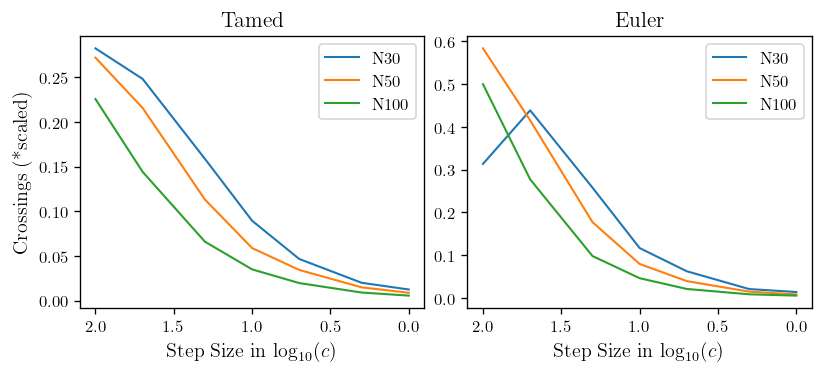

Number of trials: 1000.


In [5]:
# "scaled" is /M*N(N-1)/2 e.g. all possible combinations.
fig, axes = plt.subplots(1, 2, figsize = (6.75, 3))

for method, ax in zip(methods, axes):
    for N in N_range:
        if (N == 10):
            continue
        
        data = np.array([cross_results[(method, N, c)]["crossings"] for c in c_range])
        ax.plot(np.log10(c_range), data/(M*N*(N-1)/2), label = f"N{N}")
        
    
    ax.legend()
    ax.xaxis.set_inverted(True)
    ax.set_xlabel("Step Size in $\log_{10}(c)$")
    ax.set_title(method.capitalize())

axes[0].set_ylabel("Crossings (*scaled)")

plt.show()
print(f"Number of trials: {cross_results[("tamed", 10, 1)]["M"]}.")

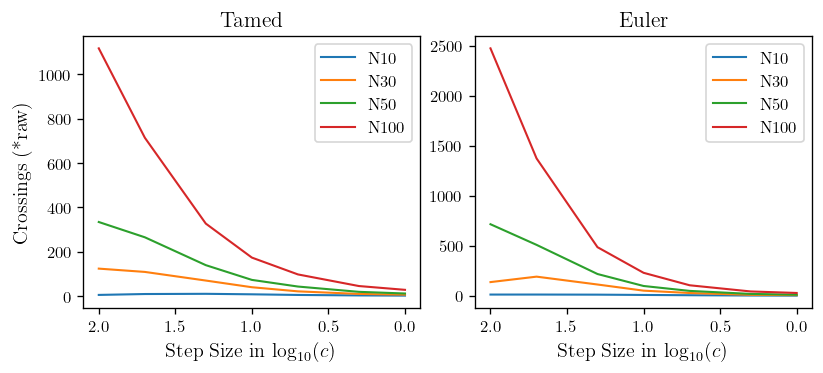

Number of trials: 1000.


In [8]:
# "raw" number of crossings is still averaged per trial.
fig, axes = plt.subplots(1, 2, figsize = (6.75, 3))

for method, ax in zip(methods, axes):
    for N in N_range:
        data = np.array([cross_results[(method, N, c)]["crossings"] for c in c_range])
        ax.plot(np.log10(c_range), data/M, label = f"N{N}")
        
    
    ax.legend()
    ax.xaxis.set_inverted(True)
    ax.set_xlabel("Step Size in $\log_{10}(c)$")
    ax.set_title(method.capitalize())

axes[0].set_ylabel("Crossings (*raw)")

plt.show()
print(f"Number of trials: {cross_results[("tamed", 10, 1)]["M"]}.")